In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("results-shap_values-2.csv")

In [3]:
# def plot_heatmap(data, title, cmap="viridis", fmt=".2f"):
#     plt.figure(figsize=(10, 6))

#     im = plt.imshow(
#         data,
#         aspect="auto",
#         origin="lower",
#         cmap=cmap
#     )

#     plt.colorbar(im, label="Most Important Index")

#     plt.xticks(
#         ticks=np.arange(len(data.columns)),
#         labels=data.columns,
#         rotation=45,
#         ha="right"
#     )
#     plt.yticks(
#         ticks=np.arange(len(data.index)),
#         labels=data.index
#     )

#     # Annotate each cell
#     for i in range(data.shape[0]):
#         for j in range(data.shape[1]):
#             val = data.iloc[i, j]
#             if not pd.isna(val):
#                 plt.text(
#                     j, i,
#                     format(val, fmt),
#                     ha="center",
#                     va="center",
#                     color="white" if val < data.values.max() * 0.7 else "black",
#                     fontsize=8
#                 )

#     plt.xlabel("Context Level")
#     plt.ylabel("Layer")
#     plt.title(title)
#     plt.tight_layout()
#     plt.show()

In [4]:
# def plot_heatmap(data, title, cmap="viridis", fmt=".0f"):
#     plt.figure(figsize=(10, 6))

#     im = plt.imshow(
#         data,
#         aspect="auto",
#         origin="lower",
#         cmap=cmap
#     )

#     plt.colorbar(im, label="Most Important Index")

#     plt.xticks(
#         ticks=np.arange(len(data.columns)),
#         labels=data.columns,
#         rotation=45,
#         ha="right"
#     )
#     plt.yticks(
#         ticks=np.arange(len(data.index)),
#         labels=data.index
#     )

#     # Annotate each cell
#     for i in range(data.shape[0]):
#         for j in range(data.shape[1]):
#             val = data.iloc[i, j]
#             if not pd.isna(val):
#                 plt.text(
#                     j, i,
#                     format(val, fmt),
#                     ha="center",
#                     va="center",
#                     color="white" if val < data.values.max() * 0.7 else "black",
#                     fontsize=8
#                 )

#     plt.xlabel("Context Level")
#     plt.ylabel("Layer")
#     plt.title(title)
#     plt.tight_layout()
#     plt.show()

In [5]:
def plot_heatmap(data, title, cmap="viridis", fmt=".0f"):
    plt.figure(figsize=(10, 6))

    values = data.values

    # Mask outliers
    masked = np.ma.masked_where(values > 512, values)

    # Copy cmap and set masked color
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad("white")

    # Color scale based only on unmasked values
    vmin = masked.min()
    vmax = masked.max()

    im = plt.imshow(
        masked,
        aspect="auto",
        origin="lower",
        cmap=cmap_obj,
        vmin=vmin,
        vmax=vmax
    )

    plt.colorbar(im, label="Most Important Index")

    plt.xticks(
        ticks=np.arange(len(data.columns)),
        labels=data.columns,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        ticks=np.arange(len(data.index)),
        labels=data.index
    )

    # Threshold for text color based only on unmasked values
    threshold = vmin + 0.7 * (vmax - vmin)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data.iloc[i, j]

            if not np.isnan(val):
                color = "white" if val < threshold else "black"

                plt.text(
                    j, i,
                    format(val, fmt),
                    ha="center",
                    va="center",
                    color=color,
                    fontsize=8
                )

    plt.xlabel("Context Level")
    plt.ylabel("Layer")
    plt.title(title)
    plt.tight_layout()
    plt.show()

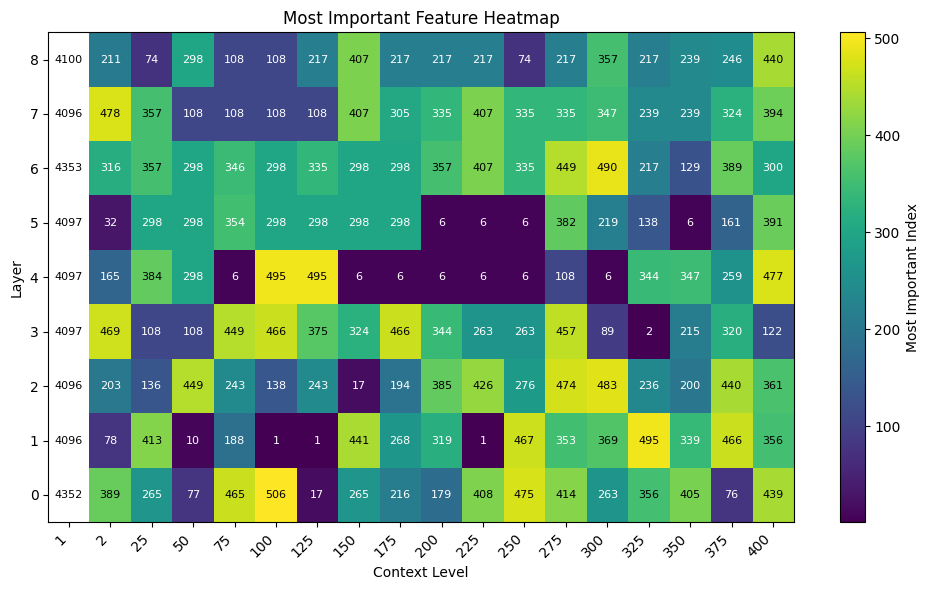

In [6]:
feat_pivot = df.pivot(
    index="Layer",
    columns="Context_Level",
    values="Most_Important_Test_Feature"
)

plot_heatmap(feat_pivot, "Most Important Feature Heatmap")

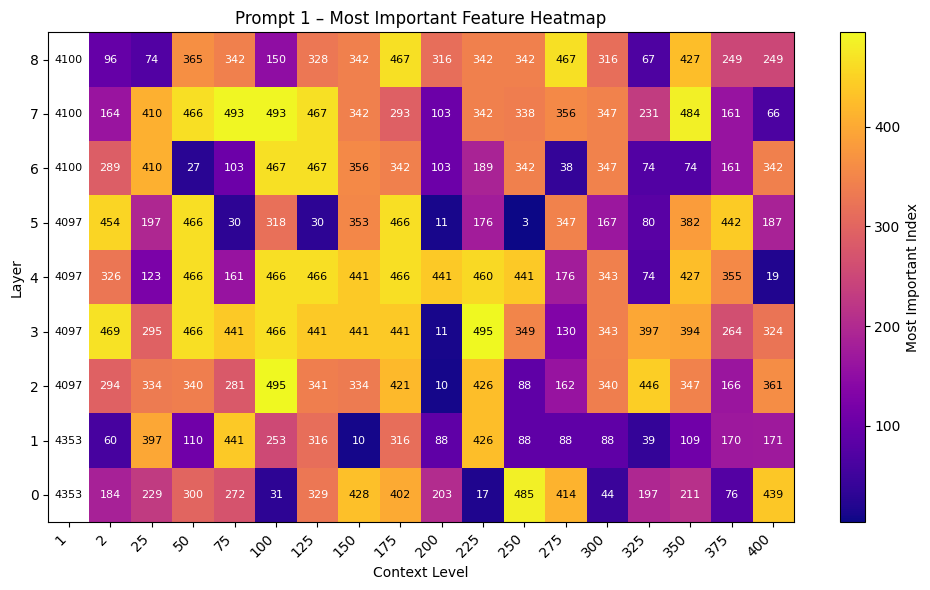

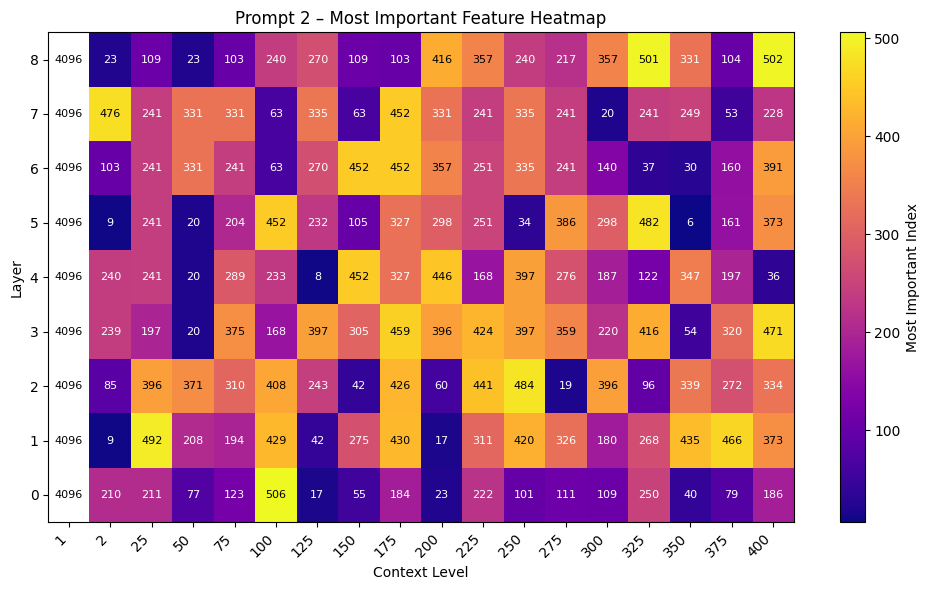

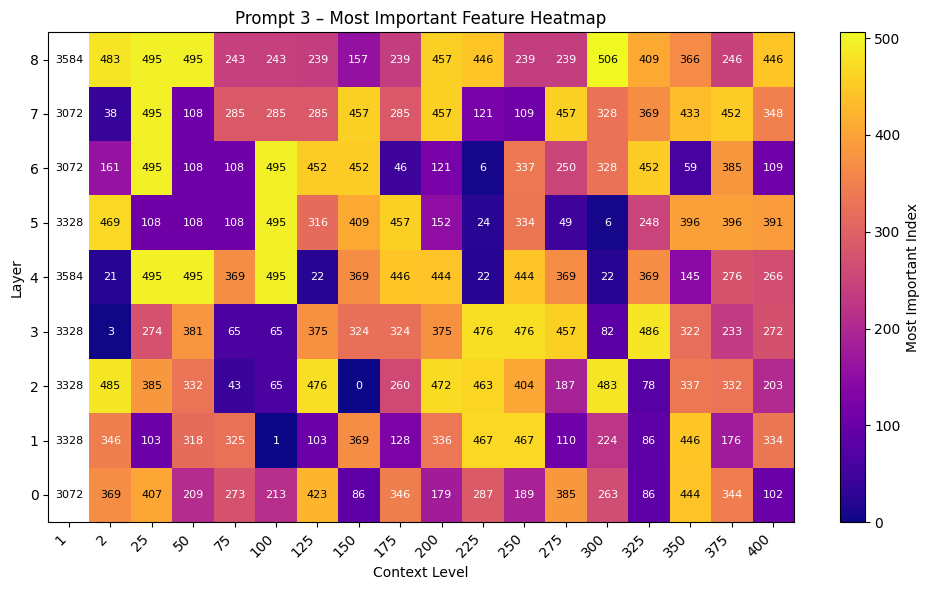

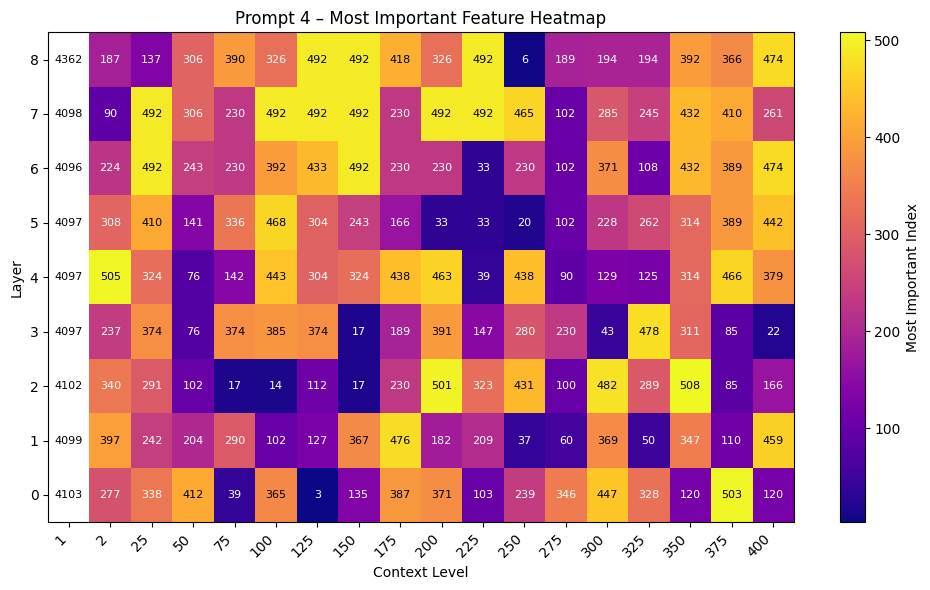

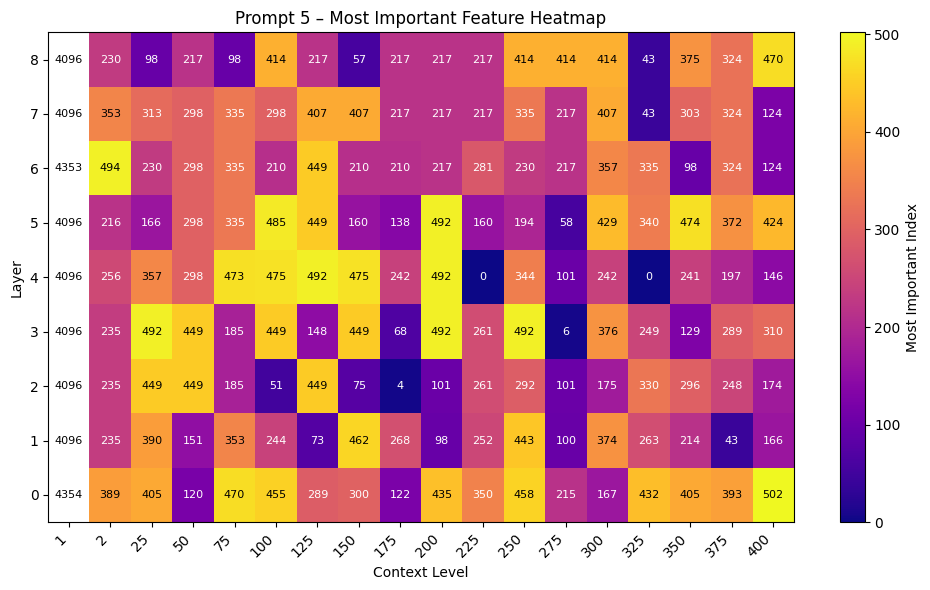

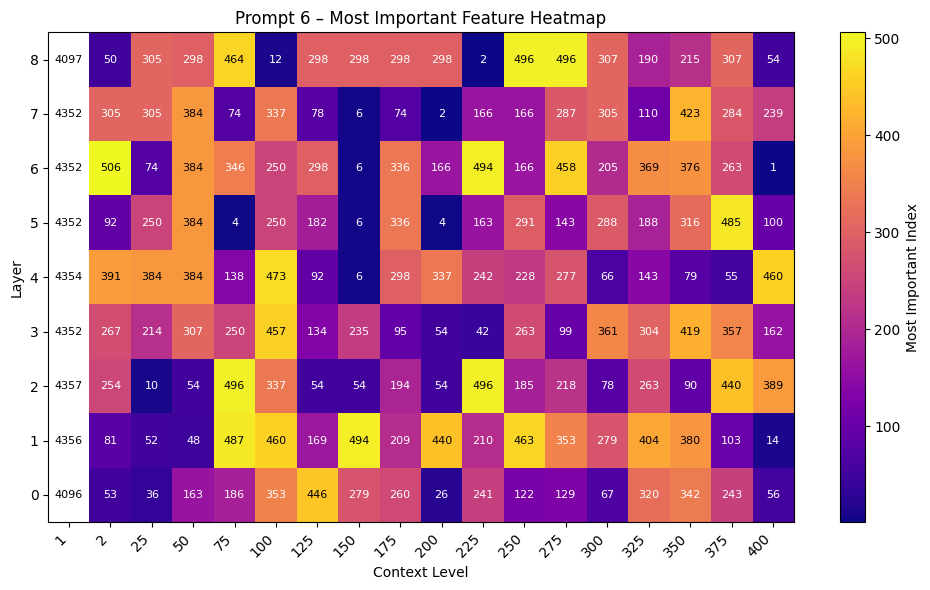

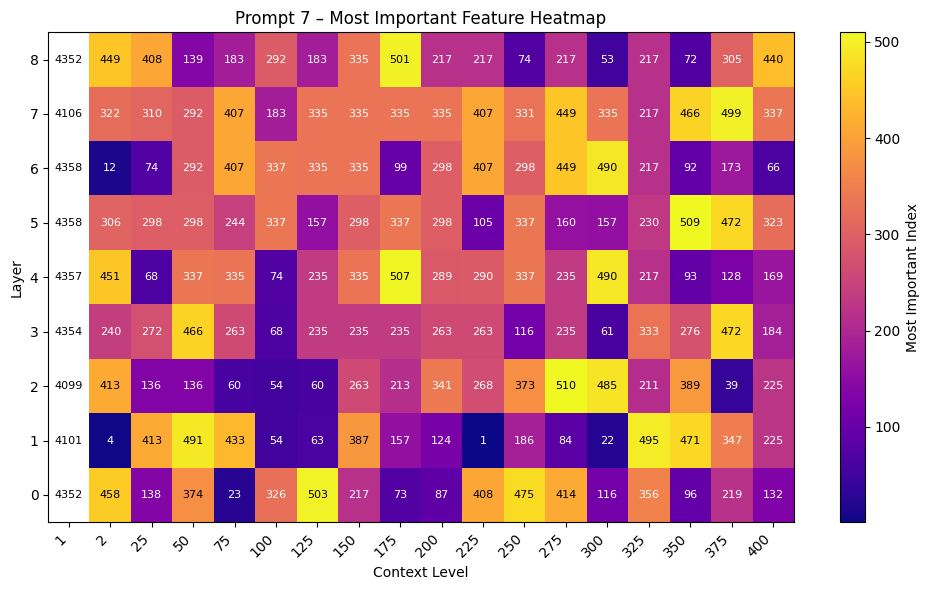

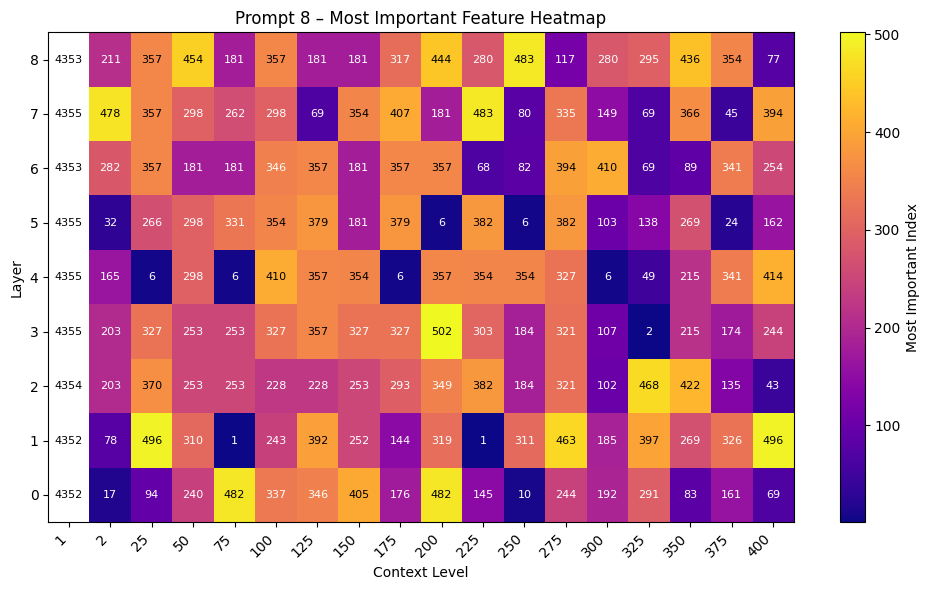

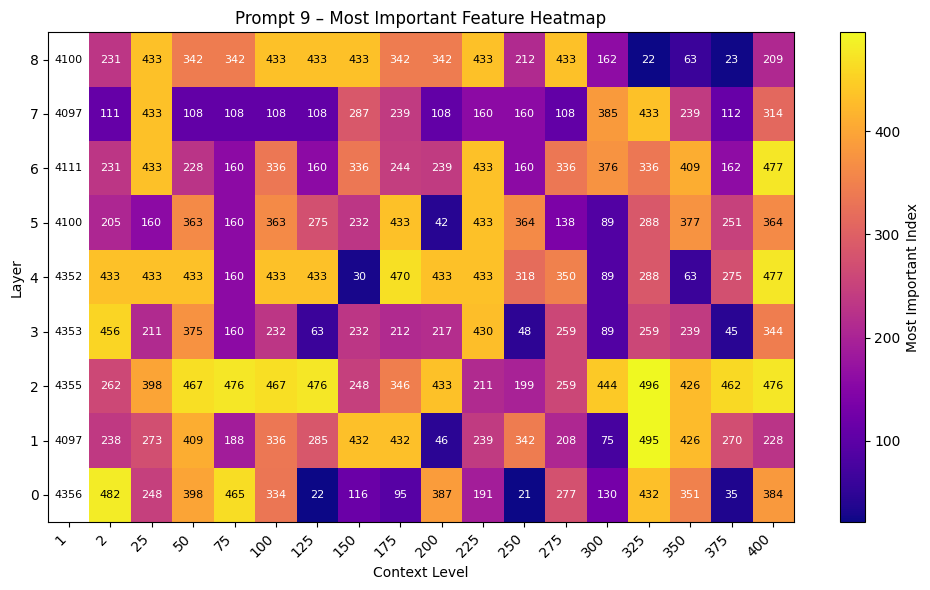

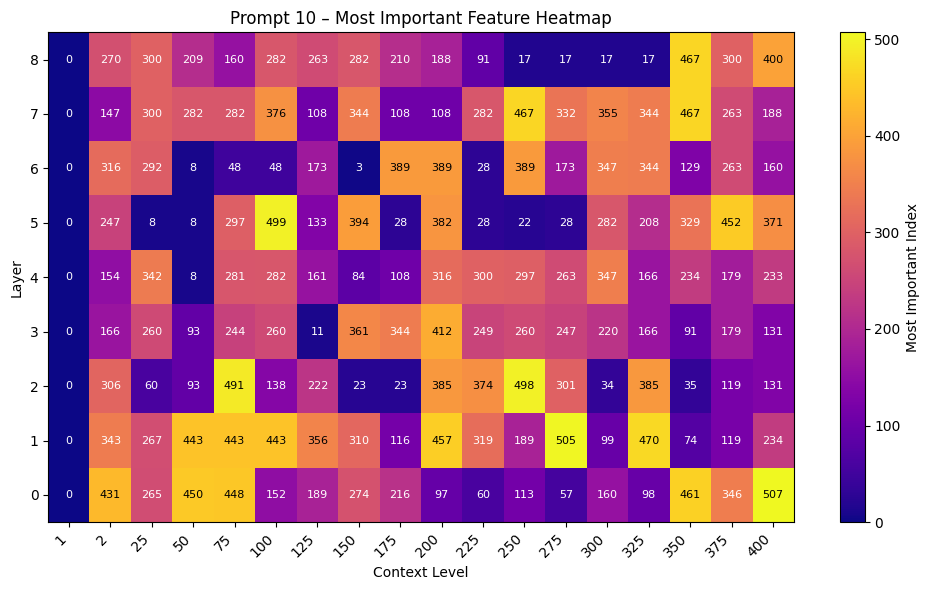

In [7]:
prompt_cols = [c for c in df.columns if c.startswith("Prompt")]

for col in prompt_cols:
    prompt_num = col.split("_")[1]

    pivot = df.pivot(
        index="Layer",
        columns="Context_Level",
        values=col
    )

    plot_heatmap(
        pivot,
        f"Prompt {prompt_num} – Most Important Feature Heatmap",
        cmap="plasma"
    )
